## Linear Regression
**Fits a linear model with coefficients to minimise the residual sum of squares** between the observed targets in the dataset. It takes in its fit method arguments X, y, sample_weight and stores the coefficients of the linear model in its coef_ and intercept_ attributes.

**The coefficient estimates for Ordinary Least Squares rely on the independence of the features.** 
* When features are correlated and some columns of the design matrix have an approximately linear dependence, the design matrix becomes close to singular and as a result, 
* the least-squares estimate becomes highly sensitive to random errors in the observed target, producing a large variance. This situation of **multicollinearity** can arise, for example, when data are collected without an experimental design.

In [3]:
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
#Create the arrays that represent the values of the x and y axis
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

In [5]:
#Execute a method that returns some important key values of Linear Regression
slope, intercept, r, p, std_err = stats.linregress(x, y)

In [6]:
# measure the correlation 
corr, _ = stats.pearsonr(x, y)
print('Pearsons correlation: %.3f' % corr)


Pearsons correlation: -0.759


In [7]:
#Create a function that uses the slope and intercept values to return a new value. 
#This new value represents where on the y-axis the corresponding x value will be placed
def myfunc(x):
  return slope * x + intercept

In [8]:
#Run each value of the x array through the function. This will result in a new array with new values for the y-axis
mymodel = list(map(myfunc, x))

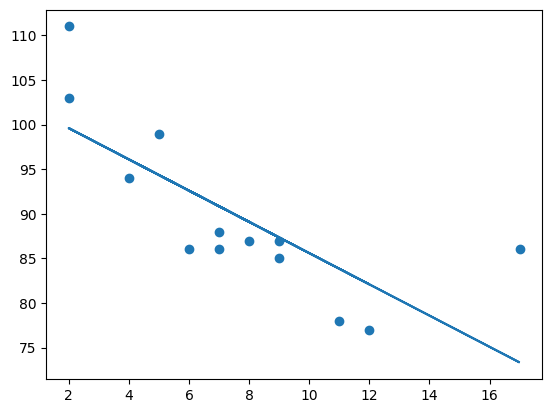

In [9]:
#Draw the original scatter plot & the line of linear regression
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()

## Predict Future Values

In [38]:
from scipy import stats

x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
  return intercept + slope * x 

speed = myfunc(20)

print(speed)

68.08020603384841


## Additional Exercise



In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [91]:
#load data
data = {
    'area': [ 1000, 1500, 2000, 2300, 2800, 3200, 3500, 4000, 4500, 5000, 5500, 6200, 7000, 8000, 9000

    ],
    'prices': [250000, 390000, 330000, 510000, 420000, 610000, 540000, 760000, 650000, 820000,    740000, 1050000, 920000, 1280000, 1190000
               ]
}

df = pd.DataFrame(data)
df

,area,prices
0,1000,250000
1,1500,390000
2,2000,330000
3,2300,510000
4,2800,420000
5,3200,610000
6,3500,540000
7,4000,760000
8,4500,650000
9,5000,820000


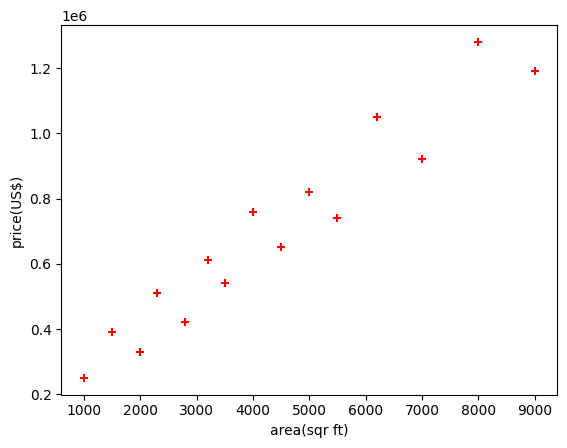

In [82]:
%matplotlib inline
plt.xlabel('area(sqr ft)')
plt.ylabel('price(US$)')
plt.scatter(df.area, df.prices, color='red', marker='+')           

via Scipy - investigate the relationship
(statistical information about the relationship)

In [83]:
from scipy import stats

X = df['area']
y = df['prices']

slope, intercept, r, p, std_err = stats.linregress(X, y)

print('Slope:', slope)
print('Intercept:', intercept)
print('Correlation:', r)
print('P-value:', p)
print('Standard error:', std_err)
print('R-squared:', r**2)

Slope: 124.3378166515389
Intercept: 154391.5339549468
Correlation: 0.9607870107412577
P-value: 1.2873796410795289e-08
Standard error: 9.952555855938934
R-squared: 0.9231116800091217


In [58]:
#prediction
predict_price_scipy = intercept + slope*3300
print(predict_price_scipy)

628715.7956313118


Scikti-learn

In [85]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Define predictors and target
X = df[['area']]
y = df['prices']

In [86]:
# 2. Create a regresssion model
model = LinearRegression()

#3. Fit model
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [87]:
# 4. Predict model
new_area = pd.DataFrame({'area': [3300]})

In [88]:
5. #Ask model to predict
prediction = model.predict(new_area)
print(prediction)

[564706.32890503]


In [89]:
# Prediction
def predict_price(area):
    return intercept + slope * area

predicted_price = predict_price(5000)
print(predicted_price)

776080.6172126413


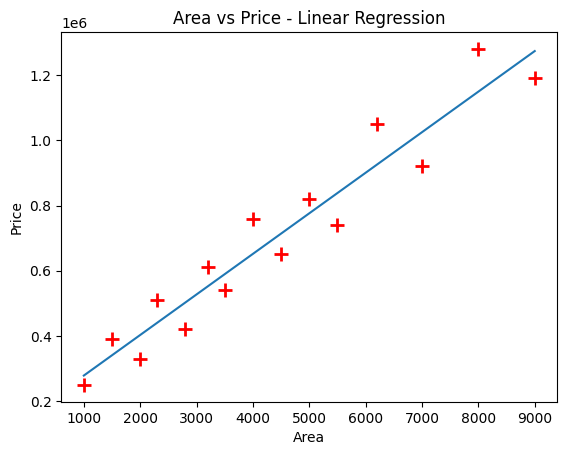

In [90]:
import matplotlib.pyplot as plt

# Original data
plt.scatter(df['area'], df['prices'], color='red', marker='+', s = 100, linewidths=2)

# Regression line
plt.plot(df['area'], model.predict(df[['area']]))
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price - Linear Regression')
plt.show()




## Exercise from scikit-learn

In [ ]:
# Linear Model
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit([[0, 0], [1, 1], [2, 2]], [0, 1, 2])
print('Coefficients:', reg.coef_)
print(f'Intercept: {reg.intercept_: .2f}')

Coefficients: [0.5 0.5]
Intercept:  0.00


In [ ]:
# Ridge Model
from sklearn import linear_model
reg = linear_model.Ridge(alpha=.5)
reg.fit([[0, 0], [0, 0], [1, 1]], [0, .1, 1])
print('Coefficients:', reg.coef_)
print(f'Intercept: {reg.intercept_: .2f}')

Coefficients: [0.34545455 0.34545455]
Intercept:  0.14


Ridge is linear regression with regularisation. It penalizes large coefficients and can be useful when predictors overlap strongly or ordinary regression becomes unstable.

## Diabates Example

In [ ]:
# Load the diabetes dataset (one feature only)
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

In [23]:
#Create a linear regression model and fit it on the training data. 
from sklearn.linear_model import LinearRegression
regressor = LinearRegression().fit(X_train, y_train)

In [ ]:
#Model evaluation using MSE (mean square error + coeffcient of determination)
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f'Mean squared error: {mean_squared_error(y_test, y_pred):.2f}')
print(f'Coefficient of determination: {r2_score(y_test, y_pred):.2f}')

Mean squared error: 2548.07
Coefficient of determination: 0.47


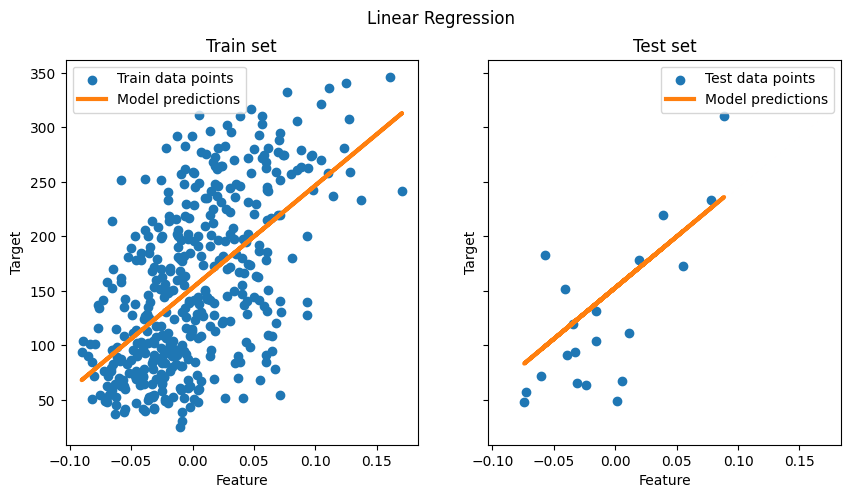

In [ ]:
# Plotting the results on the train and test data.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label='Train data points')
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color='tab:orange',
    label='Model predictions',
)
ax[0].set(xlabel='Feature', ylabel='Target', title='Train set')
ax[0].legend()

ax[1].scatter(X_test, y_test, label='Test data points')
ax[1].plot(X_test, y_pred, linewidth=3, color='tab:orange', label='Model predictions')
ax[1].set(xlabel='Feature', ylabel='Target', title='Test set')
ax[1].legend()

fig.suptitle('Linear Regression')

plt.show()

OLS on this single-feature subset learns a linear function that minimises the mean squared error on the training data. We can see how well (or poorly) it generalizes by looking at the R^2 score and mean squared error on the test set. In higher dimensions, pure OLS often overfits, especially if the data is noisy. Regularization techniques (like Ridge or Lasso) can help reduce that.

# Ordinary Least Squares vs Ridge Regression

Ridge regression addresses some of the problems of Ordinary Least Squares by imposing a penalty on the size of the coefficients. The ridge coefficients minimize a penalized residual sum of squares. The complexity parameter alpha controls the amount of shrinkage: the larger the value of the greater the amount of shrinkage and thus the coefficients become more robust to collinearity.

In [30]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

In [31]:
#data preparation
X_train = np.c_[0.5, 1].T
y_train = [0.5, 1]
X_test = np.c_[0, 2].T

np.random.seed(0)

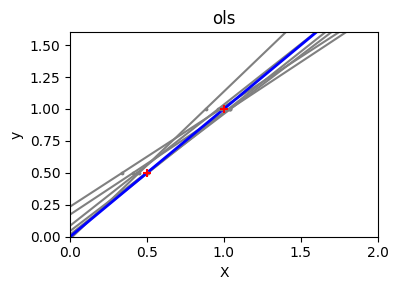

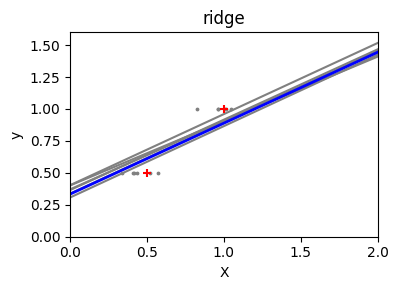

In [ ]:
# Create 2 models; alpha=0.1 controls how much regularisation Ridge applies
classifiers = dict(
    ols=linear_model.LinearRegression(), ridge=linear_model.Ridge(alpha=0.1)
)

# Looping through 2 models; creating graphs for each model 
for name, clf in classifiers.items():
    fig, ax = plt.subplots(figsize=(4, 3))

    for _ in range(6):
        this_X = 0.1 * np.random.normal(size=(2, 1)) + X_train
        clf.fit(this_X, y_train)

        ax.plot(X_test, clf.predict(X_test), color='gray')
        ax.scatter(this_X, y_train, s=3, c='gray', marker='o', zorder=10)

    clf.fit(X_train, y_train)
    ax.plot(X_test, clf.predict(X_test), linewidth=2, color='blue')
    ax.scatter(X_train, y_train, s=30, c='red', marker='+', zorder=10)

    ax.set_title(name)
    ax.set_xlim(0, 2)
    ax.set_ylim((0, 1.6))
    ax.set_xlabel('X')
    ax.set_ylabel('y')

    fig.tight_layout()

plt.show()

OLS lines varied drastically each time noise was added, reflecting its high variance when data is sparse or noisy. By contrast, Ridge regression introduces a regularization term that shrinks the coefficients, stabilizing predictions.
Techniques like Ridge or Lasso (which applies an L1 penalty) are both common ways to improve generalization and reduce overfitting. A well-tuned Ridge or Lasso often outperforms pure OLS when features are correlated, data is noisy, or sample size is small.